In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('UCS_Satellite_Database_12-1-2018-1.csv', encoding='latin1') # coloquei latin pois tem caracteres especiais no csv

# 2. Criando a variável discreta (Ano de Lançamento) extraída da data
df['Date of Launch'] = pd.to_datetime(df['Date of Launch'], errors='coerce')
df['Ano_de_Lancamento'] = df['Date of Launch'].dt.year.astype('Int64') # Int64 lida com campos vazios

# 3. Selecionando as colunas que vamos usar e removendo as linhas nulas para não quebrar o cálculo
df_limpo = df[['Ano_de_Lancamento', 'Launch Mass (kg.)']].dropna()

# 4. Renomeando a coluna de massa para facilitar o uso no código
df_limpo = df_limpo.rename(columns={'Launch Mass (kg.)': 'Massa_kg'})

print("Amostra dos Dados Limpos Prontos para Análise:")
display(df_limpo.head())

Amostra dos Dados Limpos Prontos para Análise:


/tmp/ipykernel_1127/3970809483.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date of Launch'] = pd.to_datetime(df['Date of Launch'], errors='coerce')


,Ano_de_Lancamento,Massa_kg
0,2018,4.00
1,2017,5.00
2,2016,1.00
3,2014,6.33
4,2016,1.80


## 02) Tabelas de Distribuição de Frequências

In [ ]:
freq_discreta = df_limpo['Ano_de_Lancamento'].value_counts().sort_index().to_frame(name='Freq. Absoluta (fi)')
freq_discreta['Freq. Relativa (fi%)'] = (df_limpo['Ano_de_Lancamento'].value_counts(normalize=True) * 100).round(2)
freq_discreta['Freq. Acumulada (Fi)'] = freq_discreta['Freq. Absoluta (fi)'].cumsum()
print("--- Tabela de Frequência: Ano de Lançamento (Variável Discreta) ---")
display(freq_discreta)

print("\n" + "="*60 + "\n")

# Dividindo os dados de peso em 8 classes
classes = pd.cut(df_limpo['Massa_kg'], bins=8)
freq_continua = classes.value_counts().sort_index().to_frame(name='Freq. Absoluta (fi)')
freq_continua['Freq. Relativa (fi%)'] = (classes.value_counts(normalize=True) * 100).round(2)
freq_continua['Freq. Acumulada (Fi)'] = freq_continua['Freq. Absoluta (fi)'].cumsum()
print("--- Tabela de Frequência: Massa do Satélite em kg (Variável Contínua) ---")
display(freq_continua)

--- Tabela de Frequência: Ano de Lançamento (Variável Discreta) ---


,Freq. Absoluta (fi),Freq. Relativa (fi%),Freq. Acumulada (Fi)
Ano_de_Lancamento,,,
1974,1,0.06,1
1988,1,0.06,2
1989,1,0.06,3
1990,2,0.11,5
1991,1,0.06,6
1992,1,0.06,7
1993,3,0.17,10
1994,3,0.17,13
1995,7,0.39,20




--- Tabela de Frequência: Massa do Satélite em kg (Variável Contínua) ---


,Freq. Absoluta (fi),Freq. Relativa (fi%),Freq. Acumulada (Fi)
Massa_kg,,,
"(0.021, 123.375]",1418,78.21,1418
"(123.375, 245.75]",56,3.09,1474
"(245.75, 368.125]",60,3.31,1534
"(368.125, 490.5]",34,1.88,1568
"(490.5, 612.875]",18,0.99,1586
"(612.875, 735.25]",110,6.07,1696
"(735.25, 857.625]",42,2.32,1738
"(857.625, 980.0]",75,4.14,1813


## 03) Construção de Gráficos Estatísticos

/tmp/ipykernel_1127/1308381565.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Ano_de_Lancamento', data=df_recentes, palette='viridis')


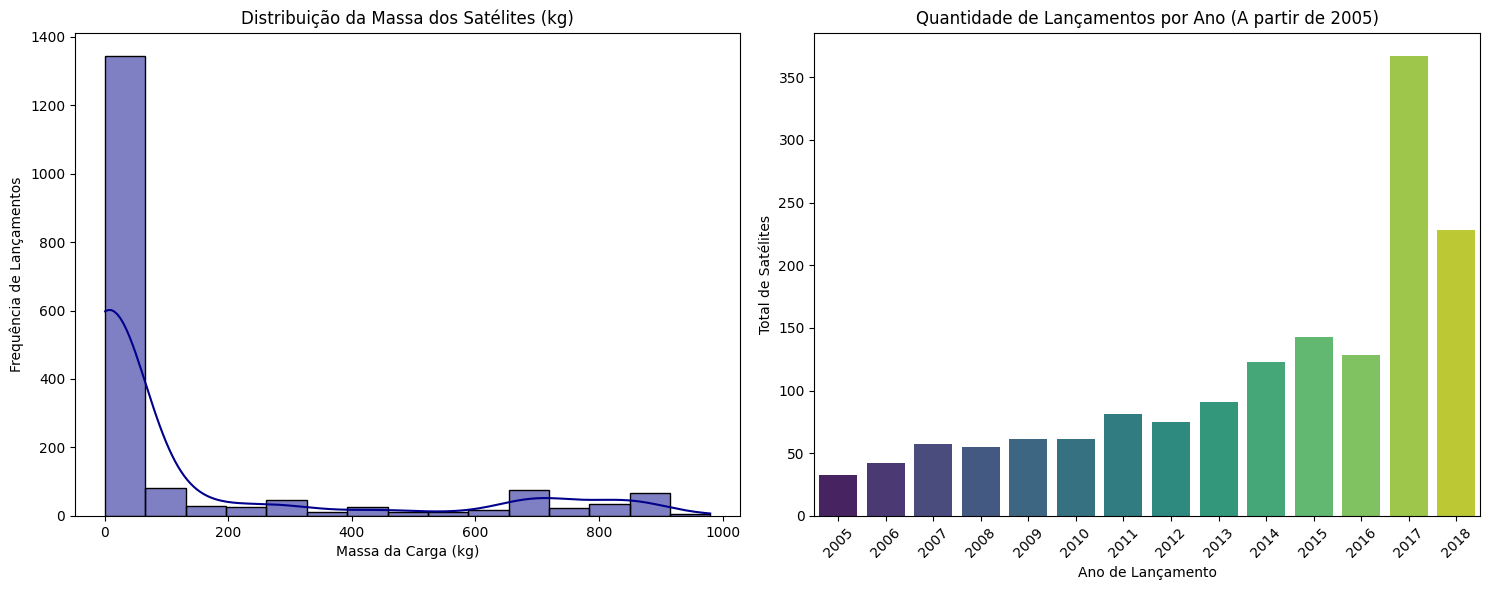

In [ ]:
plt.figure(figsize=(15, 6))

# Gráfico 1
plt.subplot(1, 2, 1)
sns.histplot(df_limpo['Massa_kg'], bins=15, kde=True, color='darkblue')
plt.title('Distribuição da Massa dos Satélites (kg)')
plt.xlabel('Massa da Carga (kg)')
plt.ylabel('Frequência de Lançamentos')

# Gráfico 2
# Para não ficar um gráfico ilegível, filtrar lançamentos a partir do ano 2005
df_recentes = df_limpo[df_limpo['Ano_de_Lancamento'] >= 2005]

plt.subplot(1, 2, 2)
sns.countplot(x='Ano_de_Lancamento', data=df_recentes, palette='viridis')
plt.title('Quantidade de Lançamentos por Ano (A partir de 2005)')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Total de Satélites')
plt.xticks(rotation=45) # Rotaciona os anos em 45 graus para caber os nomes no eixo X

plt.tight_layout()
plt.show()

## 04) Análises Univariadas utilizando Estatística Descritiva

In [ ]:
dados_analise = df_limpo['Massa_kg']

# Cálculos de Tendência Central
media = dados_analise.mean()
mediana = dados_analise.median()
moda = dados_analise.mode()[0]

# Cálculos de Dispersão
val_max = dados_analise.max()
val_min = dados_analise.min()
amplitude = val_max - val_min
variancia = dados_analise.var()
desvio_padrao = dados_analise.std()

# Medidas Separatrizes (Quartis)
q1 = dados_analise.quantile(0.25)
q2 = dados_analise.quantile(0.50) # Mediana
q3 = dados_analise.quantile(0.75)

# Exibição do Relatório Formatado
print("="*60)
print("RELATÓRIO ESTATÍSTICO: MASSA DOS SATÉLITES (kg)")
print("="*60)
print(f"\n1. TENDÊNCIA CENTRAL")
print(f"Média:   {media:.2f} kg")
print(f"Mediana: {mediana:.2f} kg")
print(f"Moda:    {moda:.2f} kg")

print(f"\n2. DISPERSÃO")
print(f"Mínimo:  {val_min} kg")
print(f"Máximo:  {val_max} kg")
print(f"Amplitude: {amplitude} kg")
print(f"Variância: {variancia:.2f}")
print(f"Desvio Padrão: {desvio_padrao:.2f} kg")

print(f"\n3. SEPARATRIZES")
print(f"Q1 (25%): {q1:.2f} kg (25% dos satélites pesam até esse valor)")
print(f"Q2 (50%): {q2:.2f} kg (Metade pesa menos, metade pesa mais)")
print(f"Q3 (75%): {q3:.2f} kg (75% dos satélites pesam até esse valor)")
print("="*60)

RELATÓRIO ESTATÍSTICO: MASSA DOS SATÉLITES (kg)

1. TENDÊNCIA CENTRAL
Média:   134.79 kg
Mediana: 5.00 kg
Moda:    3.00 kg

2. DISPERSÃO
Mínimo:  1.0 kg
Máximo:  980.0 kg
Amplitude: 979.0 kg
Variância: 68484.97
Desvio Padrão: 261.70 kg

3. SEPARATRIZES
Q1 (25%): 3.00 kg (25% dos satélites pesam até esse valor)
Q2 (50%): 5.00 kg (Metade pesa menos, metade pesa mais)
Q3 (75%): 90.00 kg (75% dos satélites pesam até esse valor)
